# Feature Engineering to beat AUC 0.838

In [97]:
# imports
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## 1. Load data + recap baseline

In [85]:
df = pd.read_csv("../data/processed/cleaned.csv")
df.head(2)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,No,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,No,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No


In [86]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [87]:
y_train = y_train.map({"No": 0, "Yes":1 })
y_test = y_test.map({"No": 0, "Yes":1 })

# Baseline to beat: LogReg AUC = 0.8383

## 2. Engineered features

### 2.1 tenure_bucket — why?
because the tenure is the strongest predictor and the relationship may not be linear.

In [88]:
df.tenure.max(), df.tenure.min()

(72, 0)

In [89]:
bin_edges = [0, 12, 24, 48, 72]
bin_labels = ['0-12', '13-24', '25-48', '49-72']

# 3. Use pd.cut to discretize the continuous data
# include_lowest=True ensures that the exact value '18' gets included in the first bin
X_train['tenure_bucket'] = pd.cut(X_train['tenure'], bins=bin_edges, labels=bin_labels, include_lowest=True)
X_test['tenure_bucket'] = pd.cut(X_test['tenure'], bins=bin_edges, labels=bin_labels, include_lowest=True)

### 2.2 services_count — why?

Services count will make us see the behavior of a user that subscribe to all of the services and compare it withe the other who doesn't.

In [90]:
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

# axis = 1, to sum them horizontally
X_train["services_count"] = (X_train[services]=="Yes").sum(axis=1)
X_test["services_count"] = (X_test[services]=="Yes").sum(axis=1)

### 2.3 is_new_customer — why?

to see if a churners tends to be new or what

In [91]:
def check_new_customer(tenure):
    if tenure < 6:
        return 1
    else:
        return 0
X_train["is_new_customer"] = X_train["tenure"].map(check_new_customer)
X_test["is_new_customer"] = X_test["tenure"].map(check_new_customer)

### 2.4 has_auto_payment — why?

customers with **automatic payment** tends to churn less.

In [92]:
def check_automatic_payment(payment_method):
    if "automatic" in payment_method:
        return 1
    else:
        return 0
X_train["has_auto_payment"] = X_train["PaymentMethod"].map(check_automatic_payment)
X_test["has_auto_payment"] = X_test["PaymentMethod"].map(check_automatic_payment)

### 2.5 monthly_charge_per_tenure — why

another aspect of seeing customers being charged related to how much they spend time with the company.

In [93]:
X_train["monthly_charge_per_tenure"] = (X_train["MonthlyCharges"]/(X_train["tenure"]+1))
X_test["monthly_charge_per_tenure"] = (X_test["MonthlyCharges"]/(X_test["tenure"]+1))

## 3. Updated preprocessing pipeline

In [94]:
num_cols = ["tenure", "MonthlyCharges","services_count", "monthly_charge_per_tenure"]
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PaperlessBilling"]
nominal_cols = ["InternetService", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod", "tenure_bucket"]

# binary map before implementing column transformer
for col in binary_cols:
    X_train[col] = X_train[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})
    X_test[col] = X_test[col].map({"Yes": 1, "No": 0, "Male": 1, "Female": 0})

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), nominal_cols)
], remainder="passthrough")
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

## 4. Evaluate

In [95]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1 Score":  f1_score(y_test, y_pred),
        "ROC AUC":   roc_auc_score(y_test, y_prob),
    }

    print(f"\n{'='*40}")
    print(f"  {model_name} Results")
    print(f"{'='*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Evaluation", fontsize=14)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False,)
    axes[0].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['ROC AUC']:.4f}")
    axes[1].plot([0,1], [0,1], '--', color='gray', alpha=0.5, label='Chance')
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return metrics


  Logistic regression model with feature engineering Results
  Accuracy    : 0.7977
  Precision   : 0.6540
  Recall      : 0.5053
  F1 Score    : 0.5701
  ROC AUC     : 0.8446


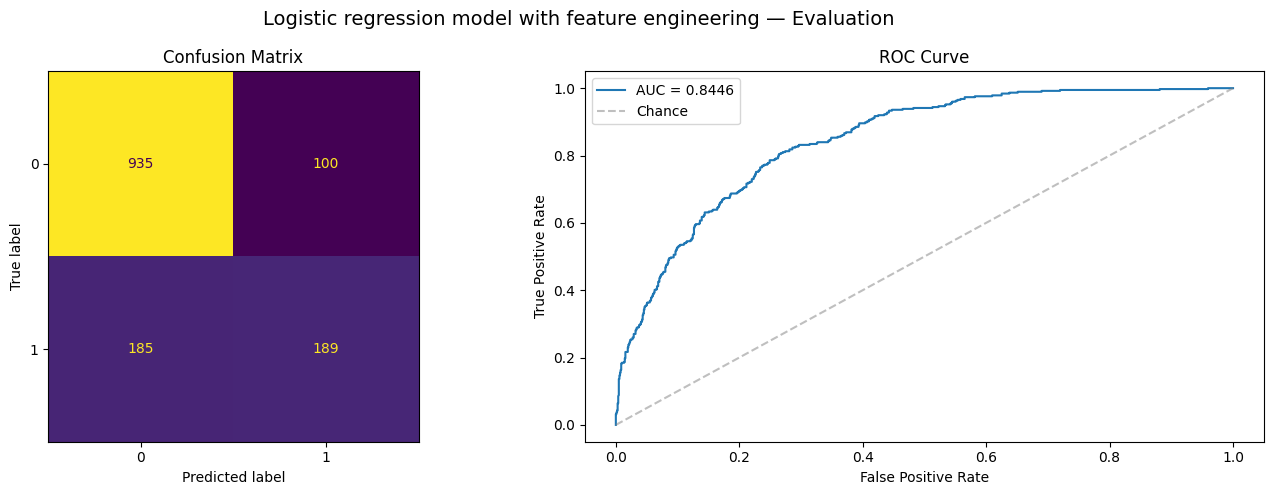

In [96]:
log_reg_features_results = evaluate_model(pipe, X_train, X_test, y_train, y_test, model_name="Logistic regression model with feature engineering")

it's obvious that the **ROC AUC** is increased. without feature engineering **(0.8383)** with feature engineering **(0.8445)**.

## 5. Comparison

<div align="center">

| Metric | LogReg+features | Logreg | Delta |
|:-------|:-----:|:------:|:-----:|
| Accuracy  | 0.7977 | 0.7977 | — |
| Precision | **0.6540** | 0.6422 | +0.0118 |
| Recall    | **0.5053** | 0.5374 | -0.0321 |
| F1 Score  | **0.5701** | 0.5852 | -0.0151 |
| ROC AUC   | **0.8446** | 0.8383 | +0.0063 |

</div>

## 6. Verdict

summary for the feature engineering step.
1. this step introduced more interesting feature, made us see the data from another prospective
2. from a business point of view, this drop in recall is actually will cost money.
3. this small increasing in delta can't be confirming that the feature engineering helped, we need cross validation technique one multiple splits to judge it.